In [1]:
# set up the python
import cosima_cookbook as cc
from dask.distributed import Client
import matplotlib.pyplot as plt
import matplotlib.path as mpath
import numpy as np
import xarray as xr
import cmocean as cm
import cartopy.crs as ccrs
import cmocean as cm
import cartopy.feature as cft
import cftime
import IPython.display
import sys, os, warnings
import matplotlib.animation as animation
from cartopy.mpl.geoaxes import GeoAxes  # Import GeoAxes for Cartopy plotting
from mpl_toolkits.axes_grid1 import AxesGrid
import gsw
from xgcm import Grid

In [2]:
client = Client(n_workers=28)
client

Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: /proxy/8787/status,
Dashboard: /proxy/8787/status,Workers: 28
Total threads: 28,Total memory: 251.19 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:46133,Workers: 28
Dashboard: /proxy/8787/status,Total threads: 28
Started: Just now,Total memory: 251.19 GiB
Comm: tcp://127.0.0.1:45149,Total threads: 1
Dashboard: /proxy/45271/status,Memory: 8.97 GiB
Nanny: tcp://127.0.0.1:45951,


In [3]:
session = cc.database.create_session()
db = '/g/data/x77/hm1221/CDW_changes/Jupyter_notebooks/RYF_perturbation.db'
session1 = cc.database.create_session(db)

In [4]:
new_coord = xr.open_dataarray('/scratch/x77/hm1221/nc_files/lat_to_shelf_bin.nc')

In [5]:
# time period for map
start_time = '2160-01-01'
end_time = '2164-12-31'

In [6]:
## Get shelf mask
x_shelf = np.loadtxt('/scratch/x77/hm1221/nc_files/x_shelf.txt')
y_shelf = np.loadtxt('/scratch/x77/hm1221/nc_files/y_shelf.txt')

# First, look at the bottom age

In [7]:
age_ctrl = cc.querying.getvar(expt='01deg_jra55v13_ryf9091', variable='age_global', 
                          session=session, frequency='1 monthly',
                          attrs={'cell_methods': 'time: mean'},
                          start_time='2160-01-01 00:00:00', 
                          end_time='2164-12-31 00:00:00')
age_wt = cc.querying.getvar(expt='01deg_jra55v13_ryf9091_ssp585', variable='age_global', 
                          session=session, frequency='1 monthly',
                          attrs={'cell_methods': 'time: mean'},
                          start_time='2160-01-01 00:00:00', 
                          end_time='2164-12-31 00:00:00')

age_th = cc.querying.getvar(expt='01deg_jra55v13_ryf9091_ssp585_th', variable='age_global', 
                          session=session, frequency='1 monthly',
                          attrs={'cell_methods': 'time: mean'},
                          start_time='2160-01-01 00:00:00', 
                          end_time='2164-12-31 00:00:00')

/g/data/xp65/public/apps/med_conda/envs/analysis3-24.07/lib/python3.11/site-packages/xarray/backends/api.py:365: UserWarning: The specified chunks separate the stored chunks along dimension "time" starting at index 1. This could degrade performance. Instead, consider rechunking after loading.
  var_chunks = _get_chunk(var, chunks, chunkmanager)
/g/data/xp65/public/apps/med_conda/envs/analysis3-24.07/lib/python3.11/site-packages/xarray/backends/api.py:365: UserWarning: The specified chunks separate the stored chunks along dimension "time" starting at index 1. This could degrade performance. Instead, consider rechunking after loading.
  var_chunks = _get_chunk(var, chunks, chunkmanager)
/g/data/xp65/public/apps/med_conda/envs/analysis3-24.07/lib/python3.11/site-packages/xarray/backends/api.py:365: UserWarning: The specified chunks separate the stored chunks along dimension "time" starting at index 1. This could degrade performance. Instead, consider rechunking after loading.
  var_chunks

In [8]:
def var_mean_5yr(var):
    var_mean_5yr = var.sel(yt_ocean = slice(-90,-50)).sel(time = slice(start_time,end_time)).mean('time').load()

    return var_mean_5yr

In [9]:
age_ctrl_mean = var_mean_5yr(age_ctrl)
age_th_mean = var_mean_5yr(age_th)
age_wt_mean = var_mean_5yr(age_wt)

In [11]:
new_coord = xr.open_dataarray('/scratch/x77/hm1221/nc_files/lat_to_shelf_bin.nc')
new_coord = new_coord.sel(yt_ocean = slice(-90,-40))

In [12]:
# transfer the data to latitude to shelf
def Trans_lat_to_shelf(var,new_coord):
    target_bin = np.arange(-20.,60,0.1)
    ds = xr.Dataset({'var': var, 'new_coord': new_coord})
    grid = Grid(ds, coords={'Y': {'center':'yt_ocean'}}, periodic=False)
    # transfer vars 
    var_new = grid.transform(ds['var'], 'Y', target_bin, target_data=ds['new_coord'],method='linear')
    var_new = var_new.rename({'new_coord': 'yt_ocean'})
    var_new_1 = var_new.sel(xt_ocean = slice(-40,80))
    var_new_2 = var_new.sel(xt_ocean = slice(-280,-60))
    var_new = xr.concat([var_new_2,var_new_1],dim = 'xt_ocean')
    var_mean  = var_new.mean('xt_ocean').load()

    return [var_new,var_mean]

In [13]:
age_ctrl_new,age_ctrl_mean_new = Trans_lat_to_shelf(age_ctrl_mean,new_coord)
age_th_new,age_th_mean_new = Trans_lat_to_shelf(age_th_mean,new_coord)
age_wt_new,age_wt_mean_new = Trans_lat_to_shelf(age_wt_mean,new_coord)

  warnings.warn(

  warnings.warn(

  warnings.warn(



In [14]:
land_1 = xr.where(np.isnan(age_ctrl_mean_new[1:,:].rename('land')),1, np.nan)

In [15]:
bound_up = xr.open_dataarray('/scratch/x77/hm1221/nc_files/bound_up.nc')
bound_low= xr.open_dataarray('/scratch/x77/hm1221/nc_files/bound_low.nc')

In [16]:
rho_ctrl_mean_new=xr.open_dataarray("/scratch/x77/hm1221/nc_files/rho_ctrl_mean_new.nc")
rho_wt_mean_new=xr.open_dataarray("/scratch/x77/hm1221/nc_files/rho_wt_mean_new.nc")
rho_th_new_mean=xr.open_dataarray("/scratch/x77/hm1221/nc_files/rho_th_new_mean.nc")

In [17]:
levs_dens = [32.0,32.3,32.5]
manual_positions = [
    (12, 200), 
    (12, 1000),
    (14,2000)
]

In [25]:
background_1 = xr.DataArray(
    data=np.ones_like(age_ctrl_mean_new),
    coords=age_ctrl_mean_new.coords,
    dims=age_ctrl_mean_new.dims,
    name='ones_array'
)

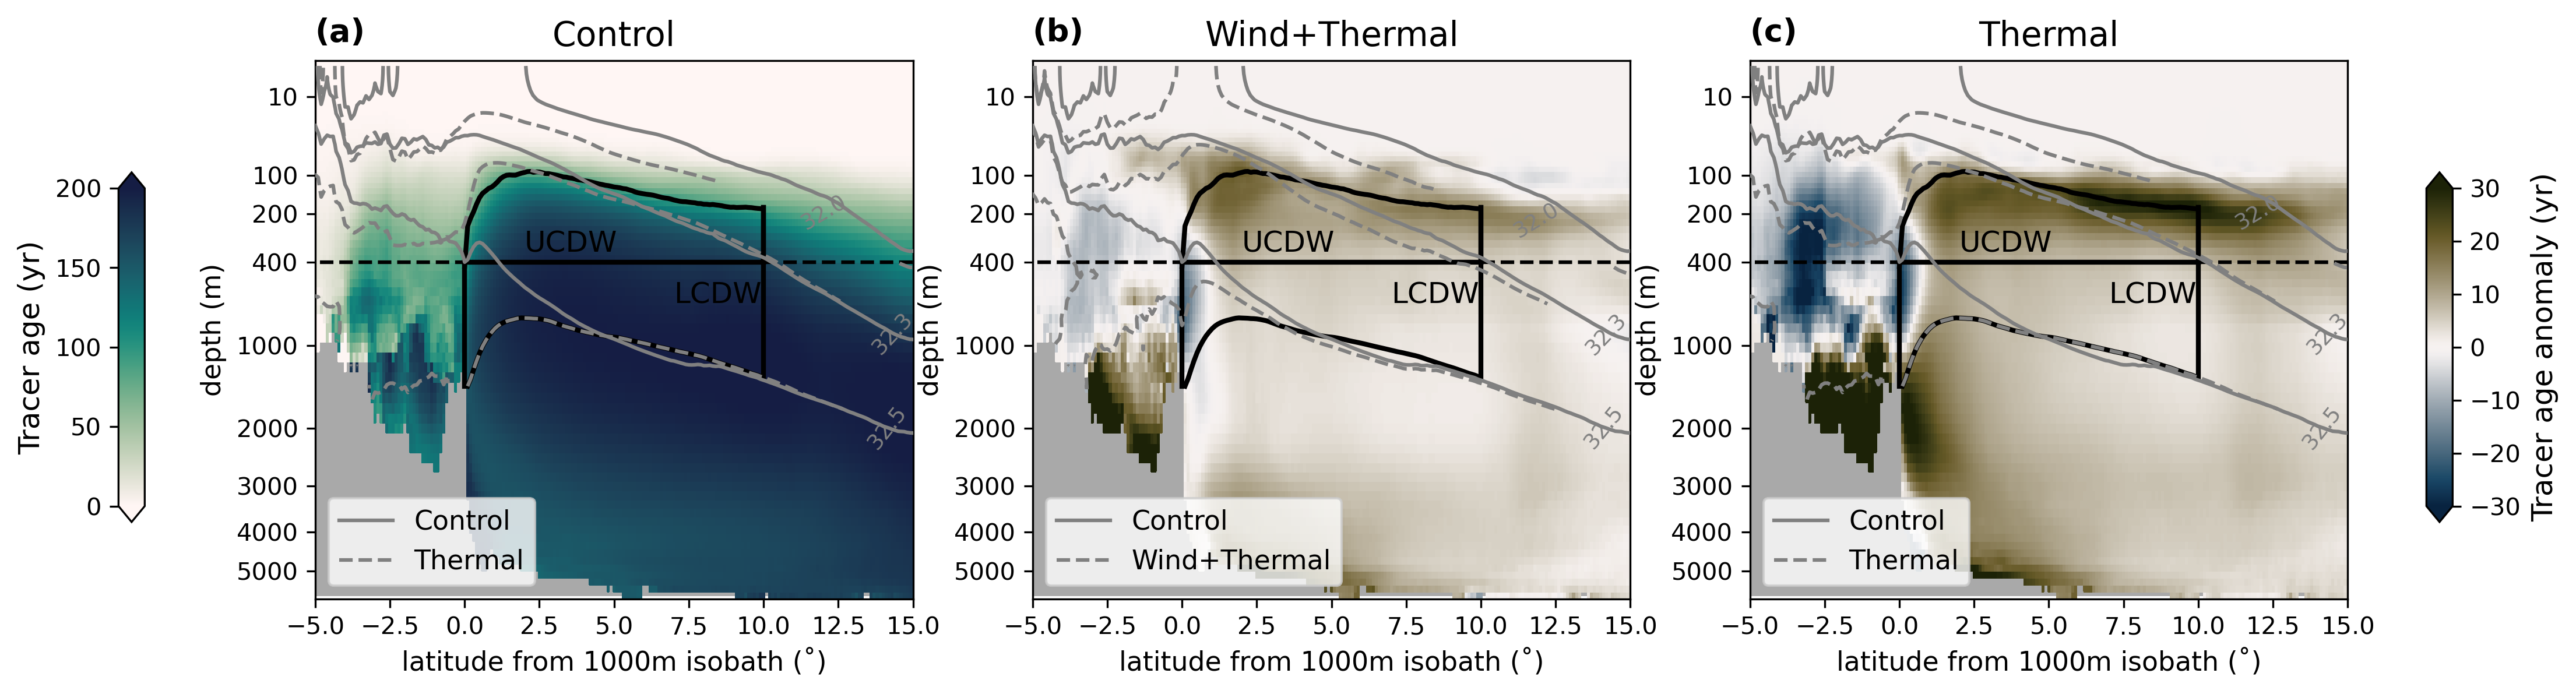

In [26]:
# For Figure S5

fig = plt.figure(figsize=(15,4),dpi = 300)
# transect 
ax = plt.subplot(1,3,1)
plt.plot(0,0,color = 'grey',linestyle='-')
plt.plot(0,0,color = 'grey',linestyle='--')
plt.legend(['Control','Thermal'],
           fontsize = 11,loc = 'lower left',ncol=1)
background_1[:,:].plot.contourf(ax=ax, colors='darkgrey', zorder=0,
                        add_colorbar=False)
p1 = (age_ctrl_mean_new.sel(st_ocean = slice(1.,8000))).plot(vmin=0,vmax=200, cmap = cm.cm.tempo,add_colorbar = False)
c2 = plt.contour(rho_ctrl_mean_new.yt_ocean.values,rho_ctrl_mean_new[1:75,:].st_ocean.values,rho_ctrl_mean_new.sel(st_ocean = slice(1.,8000)),levels=levs_dens,colors='grey',linestyles='-',linewidths=1.5,zorder=5)
c2 = plt.contour(rho_ctrl_mean_new.yt_ocean.values,rho_ctrl_mean_new[1:75,:].st_ocean.values,rho_th_new_mean.sel(st_ocean = slice(1.,8000)),levels=levs_dens,colors='grey',linestyles='--',linewidths=1.5,zorder=5)
plt.clabel(c2,fontsize=9,inline=True,fmt='%1.1f',levels=levs_dens,manual = manual_positions)
land_1[:,:].plot.contourf(ax=ax, colors='darkgrey', zorder=2,
                        add_colorbar=False)
#ax1.text(0.367,2.55,'Heat budget',fontsize = 11,color = 'k',fontweight='bold')
plt.yticks([10.,1000,2000,3000,4000,5000], [10.,1000,2000,3000,4000,5000])  
def forward(x):
    return x**(1/3)
def inverse(x):
    return x**3
plt.gca().set_yscale('function', functions=(forward, inverse))
plt.gca().invert_yaxis()
plt.xlabel('latitude from 1000m isobath (˚)', fontsize = 11)
plt.ylabel('depth (m)', fontsize = 11)
plt.xlim(-5,15)
plt.yticks([10,100,200,400,1000,2000,3000,4000,5000], [10,100,200,400,1000,2000,3000,4000,5000])  
plt.plot([-10,20], [400,400], linestyle='--', color='k')
plt.plot(bound_up[200:300].yt_ocean.values, bound_up[200:300].values, c = 'k',linewidth=2)
plt.plot([10,10],[180,400], c = 'k',linewidth=2)
plt.plot([10,10],[180,400], c = 'k',linewidth=2)
plt.plot([0,10],[400,400], c = 'k',linewidth=2)
plt.text(2,350,'UCDW',fontsize = 12,color = 'k')
plt.text(7,650,'LCDW',fontsize = 12,color = 'k')
plt.plot(bound_low[200:300].yt_ocean.values, bound_low[200:300].values, c = 'k',linewidth=2)
plt.plot([10,10],[400,bound_low[300].values], c = 'k',linewidth=2)
plt.plot([0,0],[400,bound_low[201].values], c = 'k',linewidth=2)
#plt.ylabel(' ', fontsize = 12)
ax.set_title('Control', fontsize = 14)
ax.text(
       0.0, 1.08, '(a)', transform=ax.transAxes, fontweight='bold', 
        fontsize=13,  # Font size
        verticalalignment='top',  # Align text vertically to the top
        horizontalalignment='left',  # Align text horizontally to the left
)

ax = plt.subplot(1,3,2)
plt.plot(0,0,color = 'grey',linestyle='-')
plt.plot(0,0,color = 'grey',linestyle='--')
plt.legend(['Control','Wind+Thermal'],
           fontsize = 11,loc = 'lower left',ncol=1)
background_1[:,:].plot.contourf(ax=ax, colors='darkgrey', zorder=0,
                        add_colorbar=False)
p2 = (age_wt_mean_new.sel(st_ocean = slice(1.,8000))-age_ctrl_mean_new.sel(st_ocean = slice(1.,8000))).plot(vmin=-30,vmax=30, cmap = cm.cm.diff,add_colorbar = False)
c2 = plt.contour(rho_ctrl_mean_new.yt_ocean.values,rho_ctrl_mean_new[1:75,:].st_ocean.values,rho_ctrl_mean_new.sel(st_ocean = slice(1.,8000)),levels=levs_dens,colors='grey',linestyles='-',linewidths=1.5,zorder=5)
c2 = plt.contour(rho_ctrl_mean_new.yt_ocean.values,rho_ctrl_mean_new[1:75,:].st_ocean.values,rho_wt_mean_new.sel(st_ocean = slice(1.,8000)),levels=levs_dens,colors='grey',linestyles='--',linewidths=1.5,zorder=5)
plt.clabel(c2,fontsize=9,inline=True,fmt='%1.1f',levels=levs_dens,manual = manual_positions)
land_1[:,:].plot.contourf(ax=ax, colors='darkgrey', zorder=2,
                        add_colorbar=False)
#ax1.text(0.367,2.55,'Heat budget',fontsize = 11,color = 'k',fontweight='bold')
plt.yticks([10.,1000,2000,3000,4000,5000], [10.,1000,2000,3000,4000,5000])  
def forward(x):
    return x**(1/3)
def inverse(x):
    return x**3
plt.gca().set_yscale('function', functions=(forward, inverse))
plt.gca().invert_yaxis()
plt.xlabel('latitude from 1000m isobath (˚)', fontsize = 11)
plt.ylabel('depth (m)', fontsize = 11)
plt.xlim(-5,15)
plt.yticks([10,100,200,400,1000,2000,3000,4000,5000], [10,100,200,400,1000,2000,3000,4000,5000])  
plt.plot([-10,20], [400,400], linestyle='--', color='k')
plt.plot(bound_up[200:300].yt_ocean.values, bound_up[200:300].values, c = 'k',linewidth=2)
plt.plot([10,10],[180,400], c = 'k',linewidth=2)
plt.plot([10,10],[180,400], c = 'k',linewidth=2)
plt.plot([0,10],[400,400], c = 'k',linewidth=2)
plt.text(2,350,'UCDW',fontsize = 12,color = 'k')
plt.text(7,650,'LCDW',fontsize = 12,color = 'k')
plt.plot(bound_low[200:300].yt_ocean.values, bound_low[200:300].values, c = 'k',linewidth=2)
plt.plot([10,10],[400,bound_low[300].values], c = 'k',linewidth=2)
plt.plot([0,0],[400,bound_low[201].values], c = 'k',linewidth=2)
#plt.ylabel(' ', fontsize = 12)
ax.set_title('Wind+Thermal', fontsize = 14)
ax.text(
       0.0, 1.08, '(b)', transform=ax.transAxes, fontweight='bold', 
        fontsize=13,  # Font size
        verticalalignment='top',  # Align text vertically to the top
        horizontalalignment='left',  # Align text horizontally to the left
)

ax = plt.subplot(1,3,3)
plt.plot(0,0,color = 'grey',linestyle='-')
plt.plot(0,0,color = 'grey',linestyle='--')
plt.legend(['Control','Thermal'],
           fontsize = 11,loc = 'lower left',ncol=1)
background_1[:,:].plot.contourf(ax=ax, colors='darkgrey', zorder=0,
                        add_colorbar=False)
p2 = (age_th_mean_new.sel(st_ocean = slice(1.,8000))-age_ctrl_mean_new.sel(st_ocean = slice(1.,8000))).plot(vmin=-30,vmax=30, cmap = cm.cm.diff,add_colorbar = False)
c2 = plt.contour(rho_ctrl_mean_new.yt_ocean.values,rho_ctrl_mean_new[1:75,:].st_ocean.values,rho_ctrl_mean_new.sel(st_ocean = slice(1.,8000)),levels=levs_dens,colors='grey',linestyles='-',linewidths=1.5,zorder=5)
c2 = plt.contour(rho_ctrl_mean_new.yt_ocean.values,rho_ctrl_mean_new[1:75,:].st_ocean.values,rho_th_new_mean.sel(st_ocean = slice(1.,8000)),levels=levs_dens,colors='grey',linestyles='--',linewidths=1.5,zorder=5)
plt.clabel(c2,fontsize=9,inline=True,fmt='%1.1f',levels=levs_dens,manual = manual_positions)
land_1[:,:].plot.contourf(ax=ax, colors='darkgrey', zorder=2,
                        add_colorbar=False)
#ax1.text(0.367,2.55,'Heat budget',fontsize = 11,color = 'k',fontweight='bold')
plt.yticks([10.,1000,2000,3000,4000,5000], [10.,1000,2000,3000,4000,5000])  
def forward(x):
    return x**(1/3)
def inverse(x):
    return x**3
plt.gca().set_yscale('function', functions=(forward, inverse))
plt.gca().invert_yaxis()
plt.xlabel('latitude from 1000m isobath (˚)', fontsize = 11)
plt.ylabel('depth (m)', fontsize = 11)
plt.xlim(-5,15)
plt.yticks([10,100,200,400,1000,2000,3000,4000,5000], [10,100,200,400,1000,2000,3000,4000,5000])  
plt.plot([-10,20], [400,400], linestyle='--', color='k')
plt.plot(bound_up[200:300].yt_ocean.values, bound_up[200:300].values, c = 'k',linewidth=2)
plt.plot([10,10],[180,400], c = 'k',linewidth=2)
plt.plot([10,10],[180,400], c = 'k',linewidth=2)
plt.plot([0,10],[400,400], c = 'k',linewidth=2)
plt.text(2,350,'UCDW',fontsize = 12,color = 'k')
plt.text(7,650,'LCDW',fontsize = 12,color = 'k')
plt.plot(bound_low[200:300].yt_ocean.values, bound_low[200:300].values, c = 'k',linewidth=2)
plt.plot([10,10],[400,bound_low[300].values], c = 'k',linewidth=2)
plt.plot([0,0],[400,bound_low[201].values], c = 'k',linewidth=2)
#plt.ylabel(' ', fontsize = 12)
ax.set_title('Thermal', fontsize = 14)
ax.text(
       0.0, 1.08, '(c)', transform=ax.transAxes, fontweight='bold', 
        fontsize=13,  # Font size
        verticalalignment='top',  # Align text vertically to the top
        horizontalalignment='left',  # Align text horizontally to the left
)

# colorbar 
ax_cb1 = plt.axes([0.93, 0.22, 0.01, 0.5])
cb = plt.colorbar(p2, cax=ax_cb1,  orientation='vertical',extend='both')
cb.ax.set_ylabel('Tracer age anomaly (yr)', fontsize = 12)
cb.ax.yaxis.set_label_position('right')
cb.ax.yaxis.set_ticks_position('right') 

ax_cb1 = plt.axes([0.05, 0.22, 0.01, 0.5])
cb = plt.colorbar(p1, cax=ax_cb1,  orientation='vertical',extend='both')
cb.ax.set_ylabel('Tracer age (yr)', fontsize = 12)
cb.ax.yaxis.set_label_position('left')
cb.ax.yaxis.set_ticks_position('left') 